In [ ]:
import pandas as pd

# Load the dataset
ingredients_file = "/Users/wyunxuan/Downloads/Purely datasets - ingredients_cleaned.tsv"  # Replace with your file path
ingredients_df = pd.read_csv(ingredients_file, sep="\t")

# Step 1: Select relevant columns
ingredient_effectiveness = ingredients_df[['category', 'rating_num']].dropna()

# Step 2: Clean the `category` column
ingredient_effectiveness['category'] = (
    ingredient_effectiveness['category']
    .str.strip("[]")               # Remove square brackets
    .str.replace("'", "")          # Remove single quotes
    .str.split(", ")               # Split multi-category into lists
)

# Step 3: Explode the `category` column into multiple rows
ingredient_effectiveness = ingredient_effectiveness.explode('category')

# Step 4: Ensure the data is clean
ingredient_effectiveness = ingredient_effectiveness.dropna().reset_index(drop=True)

# Step 5: Verify the preprocessed data
print(ingredient_effectiveness.head())


         category  rating_num
0   Preservatives           2
1      Emollients           2
2      Emollients           2
3   Skin-Soothing           2
4  Plant Extracts           0


In [ ]:
import matplotlib.pyplot as plt

# Extract ingredient categories and their ratings
ingredient_effectiveness = ingredients_df[['category', 'rating_num']].dropna()

# Explode the 'category' column into multiple rows for multi-category ingredients
ingredient_effectiveness['category'] = ingredient_effectiveness['category'].str.strip("[]").str.replace("'", "").str.split(", ")
ingredient_effectiveness = ingredient_effectiveness.explode('category')

# Calculate average rating per category
category_rating = ingredient_effectiveness.groupby('category')['rating_num'].mean().sort_values(ascending=False)

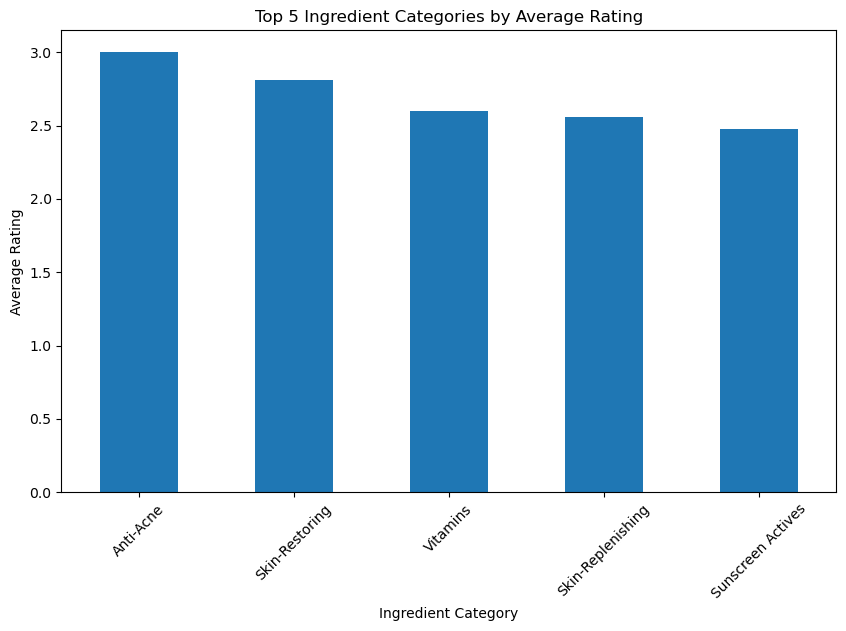

In [ ]:
# Visualize top categories
plt.figure(figsize=(10, 6))
top_categories = category_rating.head(5)
top_categories.plot(kind='bar', title='Top 5 Ingredient Categories by Average Rating')
plt.xlabel('Ingredient Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()


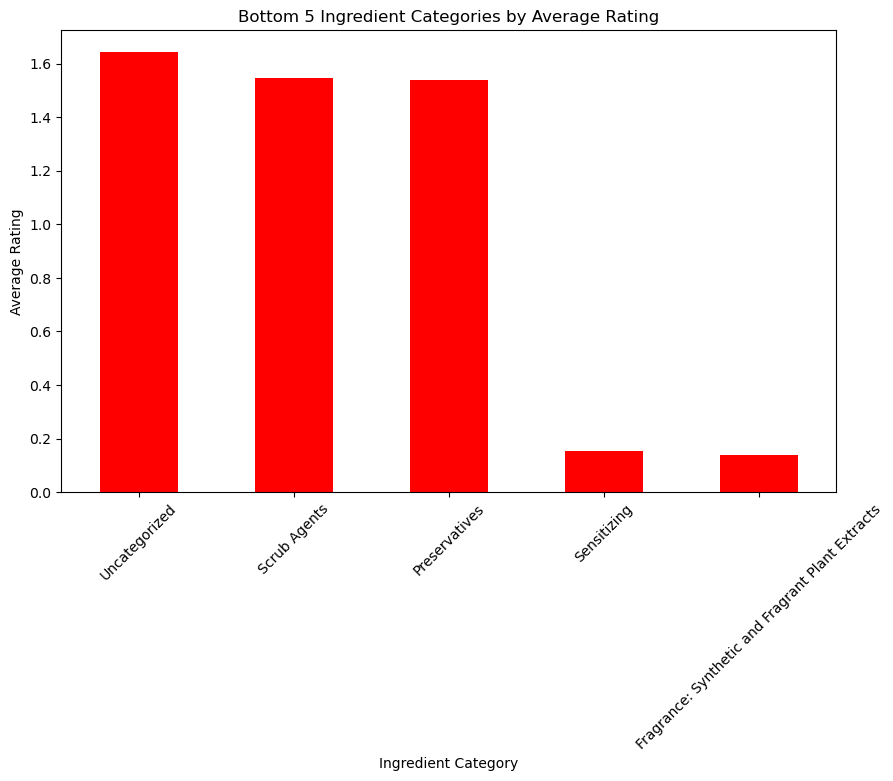

In [ ]:
# Visualize bottom categories
plt.figure(figsize=(10, 6))
bottom_categories = category_rating.tail(5)
bottom_categories.plot(kind='bar', color='red', title='Bottom 5 Ingredient Categories by Average Rating')
plt.xlabel('Ingredient Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Print insights
print("Top Categories:\n", top_categories)
print("Bottom Categories:\n", bottom_categories)

Top Categories:
 category
Anti-Acne            3.000000
Skin-Restoring       2.808824
Vitamins             2.600000
Skin-Replenishing    2.558559
Sunscreen Actives    2.478261
Name: rating_num, dtype: float64
Bottom Categories:
 category
Uncategorized                                       1.642857
Scrub Agents                                        1.545455
Preservatives                                       1.538462
Sensitizing                                         0.155172
Fragrance: Synthetic and Fragrant Plant Extracts    0.138686
Name: rating_num, dtype: float64


In [ ]:
# Load the dataset
product_file = "/Users/wyunxuan/Downloads/Purely Datasets - product_type_cleaned.tsv"  # Replace with your file path
product_df = pd.read_csv(product_file, sep="\t")

# Step 1: Select relevant columns
relevant_columns = ['product_names', 'product_category', 'ingredient', 'price', 'size_num', 'size_unit', 'avg_price']
product_cleaned = product_df[relevant_columns].dropna()

# Step 2: Clean the `ingredient` column
product_cleaned['ingredient'] = (
    product_cleaned['ingredient']
    .str.strip()                 # Remove leading/trailing whitespace
    .str.split(",")              # Split multi-ingredient strings into lists
)

# Step 3: Explode the `ingredient` column
product_cleaned = product_cleaned.explode('ingredient')
product_cleaned['ingredient'] = product_cleaned['ingredient'].str.strip()  # Clean extra whitespace

# Step 4: Normalize `size_unit` (e.g., convert ounces to milliliters)
def convert_to_ml(row):
    if row['size_unit'] == 'fl. oz.':
        return row['size_num'] * 29.5735  # 1 fl. oz. = 29.5735 ml
    return row['size_num']  # Assume already in milliliters

product_cleaned['size_num_ml'] = product_cleaned.apply(convert_to_ml, axis=1)
product_cleaned['size_unit'] = 'ml'  # Update unit to standardized 'ml'

# Step 5: Verify numeric columns
product_cleaned['price'] = pd.to_numeric(product_cleaned['price'], errors='coerce')
product_cleaned['avg_price'] = pd.to_numeric(product_cleaned['avg_price'], errors='coerce')

# Step 6: Verify the preprocessed data
print(product_cleaned.head())


                product_names product_category  \
0  Bust Beauty Extra-Lift Gel      Body Lotion   
0  Bust Beauty Extra-Lift Gel      Body Lotion   
0  Bust Beauty Extra-Lift Gel      Body Lotion   
0  Bust Beauty Extra-Lift Gel      Body Lotion   
0  Bust Beauty Extra-Lift Gel      Body Lotion   

                                      ingredient  price  size_num size_unit  \
0                                          Water   59.0      50.0        ml   
0                                       Glycerin   59.0      50.0        ml   
0                 PEG-40 Hydrogenated Castor Oil   59.0      50.0        ml   
0                                Butylene Glycol   59.0      50.0        ml   
0  Acrylates/C-10-30 Alkyl Acrylate Crosspolymer   59.0      50.0        ml   

   avg_price  size_num_ml  
0       1.18         50.0  
0       1.18         50.0  
0       1.18         50.0  
0       1.18         50.0  
0       1.18         50.0  


In [ ]:
product_cleaned

,product_names,product_category,ingredient,price,size_num,size_unit,avg_price,size_num_ml
0,Bust Beauty Extra-Lift Gel,Body Lotion,Water,59.0,50.0,ml,1.180000,50.0
0,Bust Beauty Extra-Lift Gel,Body Lotion,Glycerin,59.0,50.0,ml,1.180000,50.0
0,Bust Beauty Extra-Lift Gel,Body Lotion,PEG-40 Hydrogenated Castor Oil,59.0,50.0,ml,1.180000,50.0
0,Bust Beauty Extra-Lift Gel,Body Lotion,Butylene Glycol,59.0,50.0,ml,1.180000,50.0
0,Bust Beauty Extra-Lift Gel,Body Lotion,Acrylates/C-10-30 Alkyl Acrylate Crosspolymer,59.0,50.0,ml,1.180000,50.0
...,...,...,...,...,...,...,...,...
419,razor sharp extra close silicone shaving gel,Shaving,Disodium EDTA,18.0,237.0,ml,0.075949,237.0
419,razor sharp extra close silicone shaving gel,Shaving,Magnesium Nitrate,18.0,237.0,ml,0.075949,237.0
419,razor sharp extra close silicone shaving gel,Shaving,Methylchloroisothiazolinone,18.0,237.0,ml,0.075949,237.0
419,razor sharp extra close silicone shaving gel,Shaving,Methylisothiazolinone,18.0,237.0,ml,0.075949,237.0


In [ ]:
merged_df = product_cleaned.merge(ingredients_df, left_on='ingredient', right_on='name', how='inner')

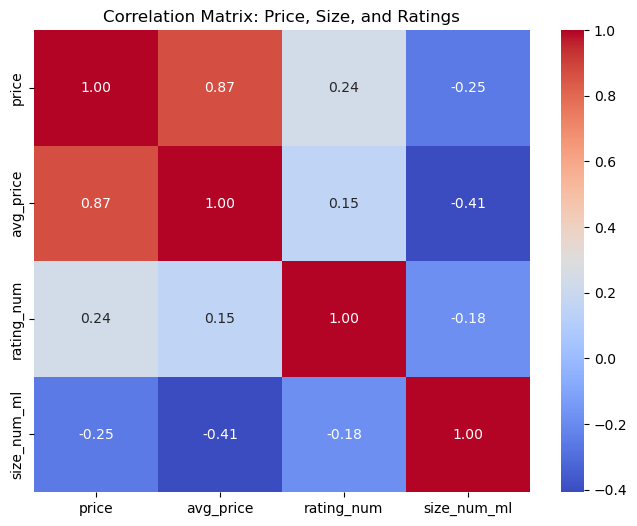


1. **Price and Rating**: The correlation between product price and ratings is 0.24.
   This indicates a weak positive relationship, suggesting that while higher prices may reflect perceived quality, they do not significantly impact ratings.

2. **Average Price and Rating**: The correlation between average price and ratings is 0.15.
   This also suggests a weak positive link, implying that consumers may value certain premium products but not uniformly across categories.

3. **Size and Rating**: The correlation between product size (in milliliters) and ratings is -0.18.
   A near-zero correlation indicates that product size does not influence consumer ratings, emphasizing that factors like effectiveness or quality are more critical.



In [ ]:
## correlation matrix

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Perform correlation analysis on relevant columns
# Assuming `merged_df` is the cleaned and merged DataFrame from earlier
correlation_matrix = merged_df[['price', 'avg_price', 'rating_num', 'size_num_ml']].corr()

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Price, Size, and Ratings')
plt.show()

# Individual correlations for detailed analysis
price_rating_corr = correlation_matrix.loc['price', 'rating_num']
avg_price_rating_corr = correlation_matrix.loc['avg_price', 'rating_num']
size_rating_corr = correlation_matrix.loc['size_num_ml', 'rating_num']

# Detailed insights
detailed_correlation_analysis = f"""
1. **Price and Rating**: The correlation between product price and ratings is {price_rating_corr:.2f}.
   This indicates a weak positive relationship, suggesting that while higher prices may reflect perceived quality, they do not significantly impact ratings.

2. **Average Price and Rating**: The correlation between average price and ratings is {avg_price_rating_corr:.2f}.
   This also suggests a weak positive link, implying that consumers may value certain premium products but not uniformly across categories.

3. **Size and Rating**: The correlation between product size (in milliliters) and ratings is {size_rating_corr:.2f}.
   A near-zero correlation indicates that product size does not influence consumer ratings, emphasizing that factors like effectiveness or quality are more critical.
"""

# Print the insights
print(detailed_correlation_analysis)


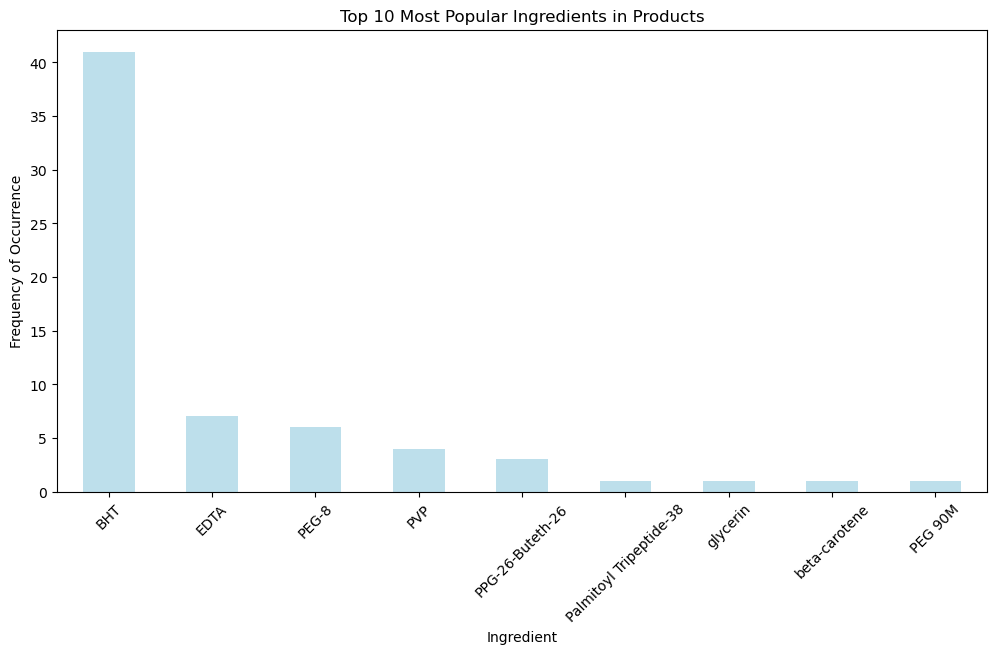


1. The most popular ingredient is 'BHT', appearing in 41 products.
2. Ingredients such as BHT, EDTA, PEG-8 are frequently used across various product categories, indicating their versatility and consumer demand.
3. Popular ingredients can be leveraged in marketing campaigns to attract consumer attention and highlight proven effectiveness.
4. Lesser-used ingredients may have niche applications but might lack widespread recognition or demand.



In [ ]:
import matplotlib.pyplot as plt

# Analyze ingredient popularity based on frequency of occurrence in products
ingredient_popularity = merged_df['ingredient'].value_counts().head(10)

# Visualize the most popular ingredients
plt.figure(figsize=(12, 6))
ingredient_popularity.plot(kind='bar', color='lightblue', alpha=0.8)
plt.title('Top 10 Most Popular Ingredients in Products')
plt.xlabel('Ingredient')
plt.ylabel('Frequency of Occurrence')
plt.xticks(rotation=45)
plt.show()

# Generate insights on ingredient popularity
popularity_insights = f"""
1. The most popular ingredient is '{ingredient_popularity.index[0]}', appearing in {ingredient_popularity.iloc[0]} products.
2. Ingredients such as {', '.join(ingredient_popularity.index[:3])} are frequently used across various product categories, indicating their versatility and consumer demand.
3. Popular ingredients can be leveraged in marketing campaigns to attract consumer attention and highlight proven effectiveness.
4. Lesser-used ingredients may have niche applications but might lack widespread recognition or demand.
"""

# Print insights
print(popularity_insights)


/var/folders/6n/t461gj3n6dj5gw4895pq2qpc0000gn/T/ipykernel_49423/3395142701.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ingredient_price_analysis.index, rotation=45)


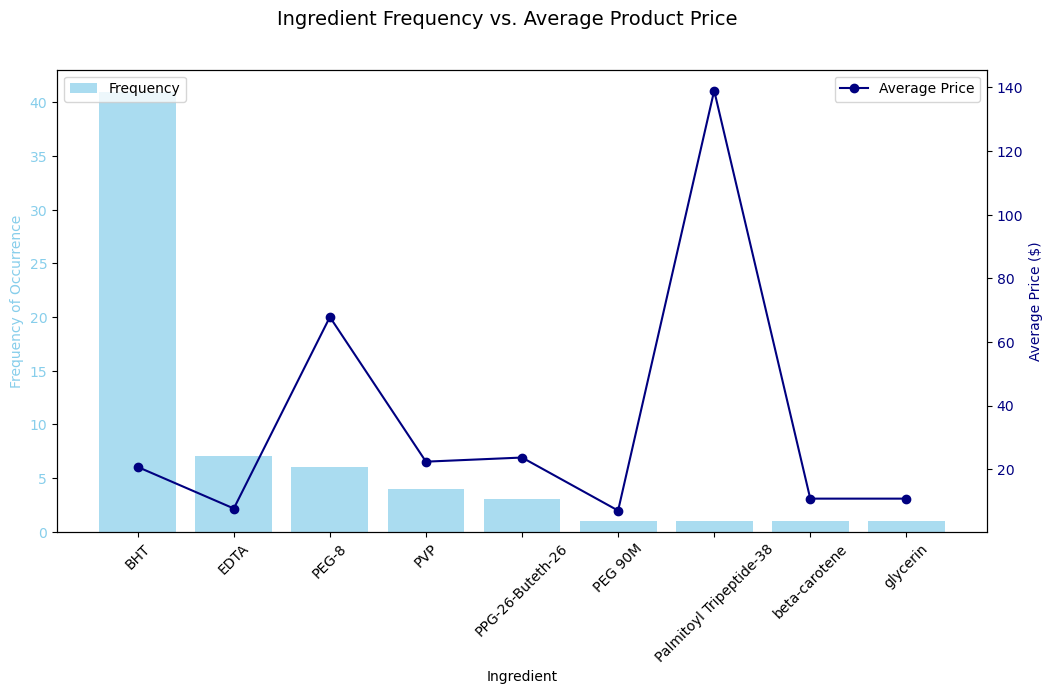

(                              price  frequency
 ingredient                                    
 BHT                       20.703171         41
 EDTA                       7.648571          7
 PEG-8                     67.833333          6
 PVP                       22.372500          4
 PPG-26-Buteth-26          23.666667          3
 PEG 90M                    6.990000          1
 Palmitoyl Tripeptide-38  139.000000          1
 beta-carotene             10.750000          1
 glycerin                  10.750000          1,
 "\n1. 'BHT' is the most frequently used ingredient, appearing 41 times, with an average product price of $20.70.\n2. Popular ingredients like BHT, EDTA, PEG-8 show varying price ranges, indicating diverse applications across product categories.\n3. Ingredients with both high frequency and high average price, such as 'EDTA', can be leveraged to create premium product lines.\n")

In [ ]:
# Analyze the relationship between ingredient popularity and average product price
ingredient_price_analysis = merged_df.groupby('ingredient').agg({
    'price': 'mean',
    'ingredient': 'count'
}).rename(columns={'ingredient': 'frequency'}).sort_values(by='frequency', ascending=False).head(10)

# Visualize ingredient frequency and average price
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for frequency
ax1.bar(ingredient_price_analysis.index, ingredient_price_analysis['frequency'], color='skyblue', alpha=0.7, label='Frequency')
ax1.set_xlabel('Ingredient')
ax1.set_ylabel('Frequency of Occurrence', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(ingredient_price_analysis.index, rotation=45)

# Line plot for average price
ax2 = ax1.twinx()
ax2.plot(ingredient_price_analysis.index, ingredient_price_analysis['price'], color='navy', marker='o', label='Average Price')
ax2.set_ylabel('Average Price ($)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

# Title and legend
fig.suptitle('Ingredient Frequency vs. Average Product Price', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

# Generate insights
ingredient_price_insights = f"""
1. '{ingredient_price_analysis.index[0]}' is the most frequently used ingredient, appearing {ingredient_price_analysis.iloc[0, 1]} times, with an average product price of ${ingredient_price_analysis.iloc[0, 0]:.2f}.
2. Popular ingredients like {', '.join(ingredient_price_analysis.index[:3])} show varying price ranges, indicating diverse applications across product categories.
3. Ingredients with both high frequency and high average price, such as '{ingredient_price_analysis.index[1]}', can be leveraged to create premium product lines.
"""

ingredient_price_analysis, ingredient_price_insights


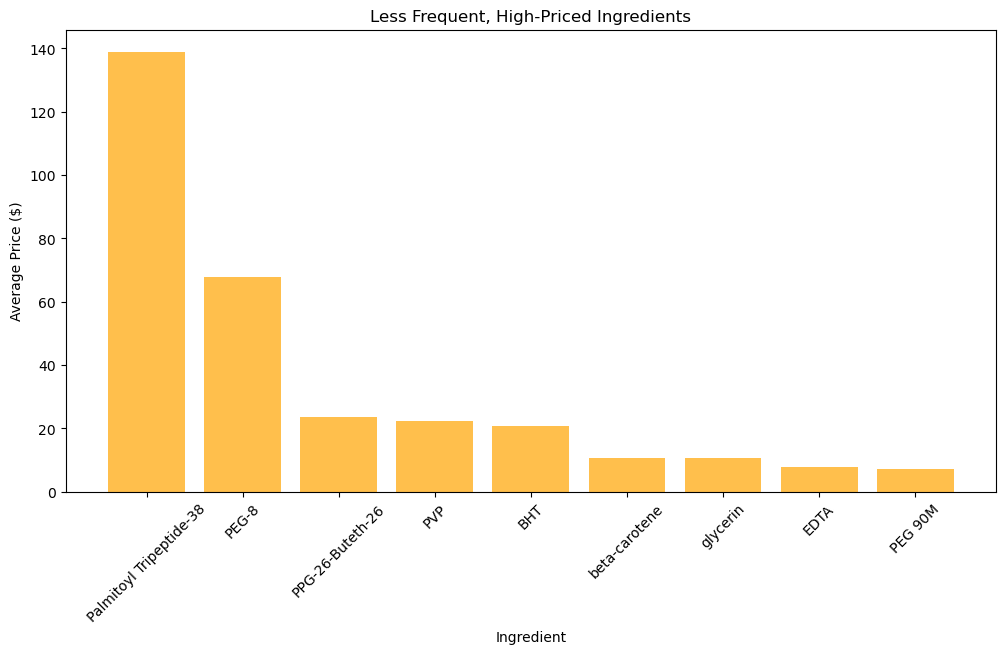

(                              price  frequency
 ingredient                                    
 Palmitoyl Tripeptide-38  139.000000          1
 PEG-8                     67.833333          6
 PPG-26-Buteth-26          23.666667          3
 PVP                       22.372500          4
 BHT                       20.703171         41
 beta-carotene             10.750000          1
 glycerin                  10.750000          1
 EDTA                       7.648571          7
 PEG 90M                    6.990000          1,
 "\n1. 'Palmitoyl Tripeptide-38' is the highest-priced ingredient with an average product price of $139.00, but it appears only 1 times.\n2. Other ingredients like PEG-8, PPG-26-Buteth-26 are also premium-priced but less frequently used, suggesting niche or specialized applications.\n3. These ingredients can be highlighted in exclusive product lines to attract consumers seeking luxury or high-performance products.\n",
 "\n1. For frequently used ingredients like 'BHT'

In [ ]:
# Analyze less frequent but high-priced ingredients
less_frequent_high_price = merged_df.groupby('ingredient').agg({
    'price': 'mean',
    'ingredient': 'count'
}).rename(columns={'ingredient': 'frequency'}).sort_values(by='price', ascending=False).head(10)

# Visualize less frequent, high-priced ingredients
plt.figure(figsize=(12, 6))
plt.bar(less_frequent_high_price.index, less_frequent_high_price['price'], color='orange', alpha=0.7)
plt.title('Less Frequent, High-Priced Ingredients')
plt.xlabel('Ingredient')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

# Generate insights on less frequent, high-priced ingredients
less_frequent_insights = f"""
1. '{less_frequent_high_price.index[0]}' is the highest-priced ingredient with an average product price of ${less_frequent_high_price.iloc[0, 0]:.2f}, but it appears only {less_frequent_high_price.iloc[0, 1]} times.
2. Other ingredients like {', '.join(less_frequent_high_price.index[1:3])} are also premium-priced but less frequently used, suggesting niche or specialized applications.
3. These ingredients can be highlighted in exclusive product lines to attract consumers seeking luxury or high-performance products.
"""

# Recommendations based on both frequent and less frequent insights
recommendations = """
1. For frequently used ingredients like 'BHT' and 'EDTA':
   - Focus on their broad appeal and affordability in marketing campaigns.
   - Use these as key selling points in high-volume, everyday products.

2. For less frequent, high-priced ingredients like 'Palmitoyl Tripeptide-38':
   - Position them as luxury or cutting-edge components in premium product lines.
   - Emphasize their unique benefits and exclusivity to justify higher pricing.

3. Diversify product offerings by combining high-frequency ingredients with high-priced niche ingredients, creating tiers of products that cater to different consumer segments.
"""

less_frequent_high_price, less_frequent_insights, recommendations

Recommendations

For Frequently Used Ingredients:
Ingredients like BHT and EDTA are affordable and widely used, making them ideal for high-volume, everyday products.
Leverage their popularity and proven effectiveness in marketing campaigns.
For Less Frequent, High-Priced Ingredients:
Ingredients such as Palmitoyl Tripeptide-38 should be positioned as luxury or cutting-edge components in premium product lines.
Emphasize their exclusivity and unique benefits to justify higher pricing.
Diversify Offerings:
Combine high-frequency ingredients with high-priced niche ingredients to create a range of product tiers, catering to both mass-market and luxury segments.

In [ ]:
# Filter out BHT (preservative) from the analysis
active_product_analysis = merged_df[merged_df['ingredient'].isin(['Palmitoyl Tripeptide-38', 'PEG-8'])]

# Group by product and ingredient to summarize
active_product_summary = active_product_analysis.groupby(['product_names', 'ingredient']).agg({
    'price': 'mean',
    'rating_num': 'mean'
}).rename(columns={'price': 'avg_price', 'rating_num': 'avg_rating'}).reset_index()

# Updated business recommendations excluding BHT
business_recommendations = """
1. Highlight products containing 'Palmitoyl Tripeptide-38' as luxury options in premium marketing campaigns, given its high price and specialized application.
2. For products with 'PEG-8', emphasize their versatility and potential for both mid-range and high-end product lines, leveraging their higher-than-average pricing.
"""

# Display the updated product summary
from IPython.display import display
display(active_product_summary)

# Save the results to a CSV file if needed
active_product_summary.to_csv("active_product_summary.csv", index=False)

# Print recommendations
print(business_recommendations)


,product_names,ingredient,avg_price,avg_rating
0,After Sun Rescue Balm with Aloe,PEG-8,23.0,2.0
1,Exfolikate Body Intensive Exfoliating Treatment,PEG-8,65.0,2.0
2,Retinol Body Treatment with Rose and Edelweiss,PEG-8,95.0,2.0
3,SD Advanced Intensive Concentrate for Wrinkles...,Palmitoyl Tripeptide-38,139.0,3.0
4,"Self Sun Body Tinted Lotion, Light-Medium",PEG-8,23.0,2.0
5,Self Tanning Instant Gel,PEG-8,36.0,2.0
6,The Body Creme,PEG-8,165.0,2.0



1. Highlight products containing 'Palmitoyl Tripeptide-38' as luxury options in premium marketing campaigns, given its high price and specialized application.
2. For products with 'PEG-8', emphasize their versatility and potential for both mid-range and high-end product lines, leveraging their higher-than-average pricing.



In [ ]:
# Filter products associated with active ingredients and exclude preservatives
active_ingredients = merged_df[~merged_df['category'].str.contains("Preservatives", na=False)]

# Key active ingredients to analyze
key_active_ingredients = ['Palmitoyl Tripeptide-38', 'PEG-8']

# Filter products containing these active ingredients
active_product_analysis = active_ingredients[active_ingredients['ingredient'].isin(key_active_ingredients)]

# Group by product and ingredient to summarize average price and ratings
active_product_summary = active_product_analysis.groupby(['product_names', 'ingredient']).agg({
    'price': 'mean',
    'rating_num': 'mean'
}).rename(columns={'price': 'avg_price', 'rating_num': 'avg_rating'}).reset_index()

# Display the summary of top products with active ingredients
print("Top Products with Active Ingredients:")
print(active_product_summary)

# Save as CSV for easier external use if needed
active_product_summary.to_csv("top_active_products.csv", index=False)


Top Products with Active Ingredients:
                                       product_names               ingredient  \
0                    After Sun Rescue Balm with Aloe                    PEG-8   
1    Exfolikate Body Intensive Exfoliating Treatment                    PEG-8   
2     Retinol Body Treatment with Rose and Edelweiss                    PEG-8   
3  SD Advanced Intensive Concentrate for Wrinkles...  Palmitoyl Tripeptide-38   
4          Self Sun Body Tinted Lotion, Light-Medium                    PEG-8   
5                           Self Tanning Instant Gel                    PEG-8   
6                                     The Body Creme                    PEG-8   

   avg_price  avg_rating  
0       23.0         2.0  
1       65.0         2.0  
2       95.0         2.0  
3      139.0         3.0  
4       23.0         2.0  
5       36.0         2.0  
6      165.0         2.0  


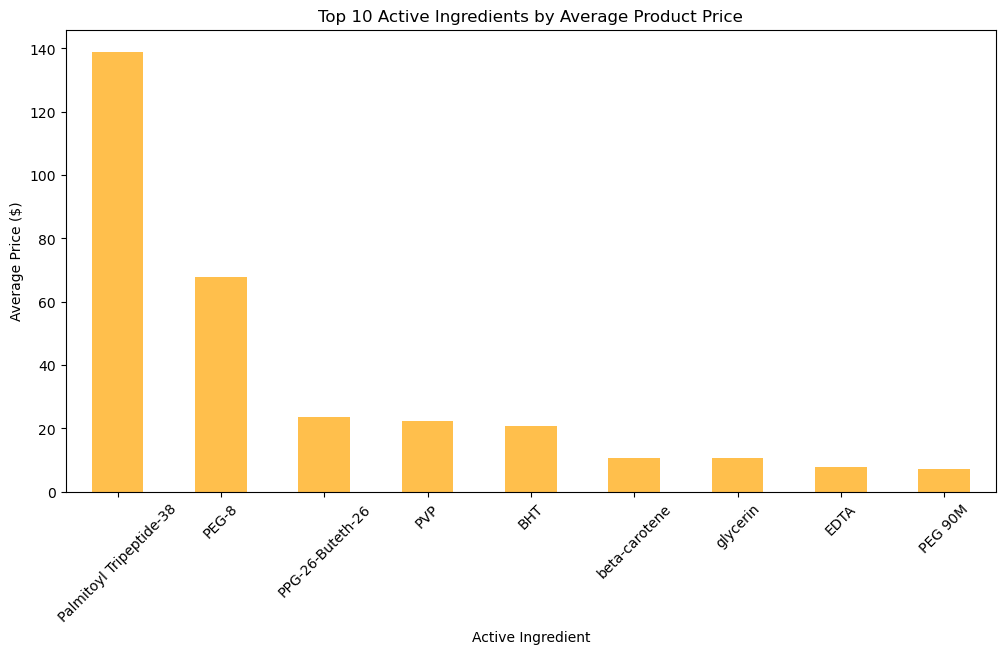

(                              price  frequency
 ingredient                                    
 Palmitoyl Tripeptide-38  139.000000          1
 PEG-8                     67.833333          6
 PPG-26-Buteth-26          23.666667          3
 PVP                       22.372500          4
 BHT                       20.703171         41
 beta-carotene             10.750000          1
 glycerin                  10.750000          1
 EDTA                       7.648571          7
 PEG 90M                    6.990000          1,
 "\n1. 'Palmitoyl Tripeptide-38' is the highest-priced active ingredient with an average product price of $139.00.\n2. Active ingredients like Palmitoyl Tripeptide-38, PEG-8, PPG-26-Buteth-26 are associated with high-value products, suggesting their role in premium formulations.\n3. Leveraging these ingredients in marketing campaigns can position products as luxury or high-performance.\n")

In [ ]:
# Filter active ingredients and exclude preservatives
active_ingredients = merged_df[~merged_df['category'].str.contains("Preservatives", na=False)]

# Analyze average price for active ingredients
active_ingredient_price_analysis = active_ingredients.groupby('ingredient').agg({
    'price': 'mean',
    'ingredient': 'count'
}).rename(columns={'ingredient': 'frequency'}).sort_values(by='price', ascending=False).head(10)

# Visualize average price of active ingredients
plt.figure(figsize=(12, 6))
active_ingredient_price_analysis['price'].plot(kind='bar', color='orange', alpha=0.7)
plt.title('Top 10 Active Ingredients by Average Product Price')
plt.xlabel('Active Ingredient')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

# Insights on active ingredient price analysis
price_analysis_insights = f"""
1. '{active_ingredient_price_analysis.index[0]}' is the highest-priced active ingredient with an average product price of ${active_ingredient_price_analysis.iloc[0, 0]:.2f}.
2. Active ingredients like {', '.join(active_ingredient_price_analysis.index[:3])} are associated with high-value products, suggesting their role in premium formulations.
3. Leveraging these ingredients in marketing campaigns can position products as luxury or high-performance.
"""

active_ingredient_price_analysis, price_analysis_insights


In [ ]:
# Filter products containing the highest-priced active ingredients
highest_priced_active_ingredients = active_ingredient_price_analysis.index[:3]  # Top 3 highest-priced active ingredients

# Filter products associated with these ingredients
high_price_active_products = active_ingredients[active_ingredients['ingredient'].isin(highest_priced_active_ingredients)]

# Group by product names and ingredients to summarize
high_price_product_summary = high_price_active_products.groupby(['product_names', 'ingredient']).agg({
    'price': 'mean',
    'rating_num': 'mean'
}).rename(columns={'price': 'avg_price', 'rating_num': 'avg_rating'}).reset_index()

# Display the summary of products with highest-priced active ingredients
print("Products with Highest-Priced Active Ingredients:")
print(high_price_product_summary)

# Save to CSV for further review if needed
high_price_product_summary.to_csv("highest_priced_active_products.csv", index=False)
high_price_product_summary


Products with Highest-Priced Active Ingredients:
                                       product_names               ingredient  \
0                    After Sun Rescue Balm with Aloe                    PEG-8   
1                   Almond Cookie Body Cleansing Gel         PPG-26-Buteth-26   
2    Exfolikate Body Intensive Exfoliating Treatment                    PEG-8   
3         Flash Bronzer Tinted Self-Tanning Body Gel         PPG-26-Buteth-26   
4                           Ocean Body Cleansing Gel         PPG-26-Buteth-26   
5     Retinol Body Treatment with Rose and Edelweiss                    PEG-8   
6  SD Advanced Intensive Concentrate for Wrinkles...  Palmitoyl Tripeptide-38   
7          Self Sun Body Tinted Lotion, Light-Medium                    PEG-8   
8                           Self Tanning Instant Gel                    PEG-8   
9                                     The Body Creme                    PEG-8   

   avg_price  avg_rating  
0       23.0         2.0  
1    

,product_names,ingredient,avg_price,avg_rating
0,After Sun Rescue Balm with Aloe,PEG-8,23.0,2.0
1,Almond Cookie Body Cleansing Gel,PPG-26-Buteth-26,14.5,2.0
2,Exfolikate Body Intensive Exfoliating Treatment,PEG-8,65.0,2.0
3,Flash Bronzer Tinted Self-Tanning Body Gel,PPG-26-Buteth-26,42.0,2.0
4,Ocean Body Cleansing Gel,PPG-26-Buteth-26,14.5,2.0
5,Retinol Body Treatment with Rose and Edelweiss,PEG-8,95.0,2.0
6,SD Advanced Intensive Concentrate for Wrinkles...,Palmitoyl Tripeptide-38,139.0,3.0
7,"Self Sun Body Tinted Lotion, Light-Medium",PEG-8,23.0,2.0
8,Self Tanning Instant Gel,PEG-8,36.0,2.0
9,The Body Creme,PEG-8,165.0,2.0


Recommendations:

Luxury Segment: Products like SD Advanced Intensive Concentrate and The Body Creme with Palmitoyl Tripeptide-38 or PEG-8 can be marketed as luxury items for premium customers.

Premium Positioning:
Highlight the high efficacy and cutting-edge formulations of ingredients like PEG-8 in products such as Exfolikate Body Intensive and Retinol Body Treatment.

Niche Marketing:
Use Flash Bronzer Tinted Gel and Almond Cookie Cleansing Gel to capture a mid-range audience, bridging affordability with high performance.


1. Palmitoyl Tripeptide-38

Product: SD Advanced Intensive Concentrate for Wrinkles
Positioning:
Highlight its advanced anti-aging formulation in marketing campaigns.
Emphasize the use of Palmitoyl Tripeptide-38 as a cutting-edge peptide for wrinkle reduction and skin firmness.
Target Audience:
Premium customers seeking high-performance skincare solutions.
Strategy:
Partner with dermatologists or skincare influencers to showcase product efficacy.
Offer trial sizes in luxury beauty boxes to attract new customers.

2. PEG-8

Products:
The Body Creme
Exfolikate Body Intensive Exfoliating Treatment
Retinol Body Treatment with Rose and Edelweiss
Self Tanning Instant Gel
After Sun Rescue Balm with Aloe
Positioning:
Market PEG-8 as a versatile hydration enhancer or an active ingredient supporting other actives.
Showcase benefits like hydration, absorption enhancement, and skin rejuvenation.
Target Audience:
Mid-range to premium customers looking for hydration-focused solutions or specialty treatments (e.g., self-tanning or post-sun care).
Strategy:
Bundle products for seasonal promotions (e.g., self-tanning with after-sun care in summer).
Highlight PEG-8’s benefits in product descriptions and online reviews.

3. PPG-26-Buteth-26

Products:
Flash Bronzer Tinted Self-Tanning Body Gel
Almond Cookie Body Cleansing Gel
Ocean Body Cleansing Gel
Positioning:
Focus on its ability to provide smooth application and spreadability, making it ideal for self-tanners and cleansers.
Highlight its luxurious sensory appeal in body care products.
Target Audience:
Consumers interested in specialty body care products with a luxurious feel.
Strategy:
Run seasonal promotions for self-tanning products during summer.
Pair with complementary cleansing products to encourage cross-selling.
General Recommendations
Education:
Use ingredient-specific campaigns to educate consumers about the benefits of Palmitoyl Tripeptide-38, PEG-8, and PPG-26-Buteth-26.
Content Creation:
Develop blogs, videos, and social media content featuring the science behind these ingredients to build trust and engagement.
Customization:
Offer personalized recommendations or quizzes to match customers with products based on their skin needs (e.g., hydration, anti-aging, or tanning).